In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("agriculture_yield_dataset.csv")

In [3]:
df.shape

(1500, 8)

In [4]:
df.columns

Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='str')

In [5]:
df.head(10)

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


In [6]:
df.dtypes

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                    str
soil_type                    str
yield_ton_per_hectare    float64
dtype: object

In [7]:
df.isnull().sum()

rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

In [8]:
df.describe()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,754.054667,27.749467,148.744067,5.403267,6.759133,5.028793
std,255.097216,5.758101,56.990279,2.584329,0.719742,0.968282
min,300.200000,18.000000,50.300000,1.000000,5.500000,2.090000
25%,536.175000,22.600000,98.600000,3.200000,6.100000,4.337500
50%,761.200000,27.700000,146.850000,5.400000,6.800000,5.010000
75%,964.375000,32.600000,196.575000,7.600000,7.400000,5.740000
max,1200.000000,38.000000,249.900000,10.000000,8.000000,7.860000


In [9]:
summary = df.describe()
summary

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,754.054667,27.749467,148.744067,5.403267,6.759133,5.028793
std,255.097216,5.758101,56.990279,2.584329,0.719742,0.968282
min,300.200000,18.000000,50.300000,1.000000,5.500000,2.090000
25%,536.175000,22.600000,98.600000,3.200000,6.100000,4.337500
50%,761.200000,27.700000,146.850000,5.400000,6.800000,5.010000
75%,964.375000,32.600000,196.575000,7.600000,7.400000,5.740000
max,1200.000000,38.000000,249.900000,10.000000,8.000000,7.860000


In [10]:
summary.loc['mean']

rainfall_mm              754.054667
temperature_c             27.749467
fertilizer_kg            148.744067
irrigation_hours           5.403267
soil_ph                    6.759133
yield_ton_per_hectare      5.028793
Name: mean, dtype: float64

In [11]:
summary.loc['mean'].idxmax()

'rainfall_mm'

In [12]:
summary.loc['std'].idxmax()

'rainfall_mm'

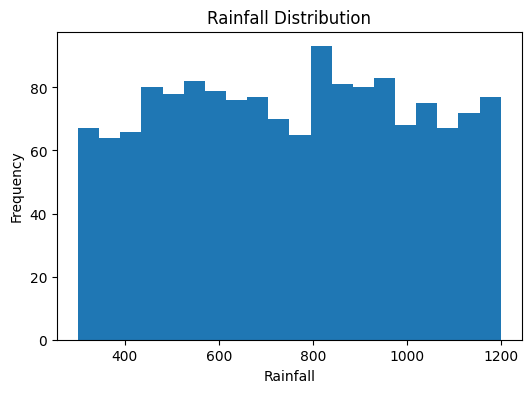

In [13]:
plt.figure(figsize=(6,4))

plt.hist(df['rainfall_mm'],
         bins=20)

plt.title("Rainfall Distribution")
plt.xlabel("Rainfall")
plt.ylabel("Frequency")

plt.show()

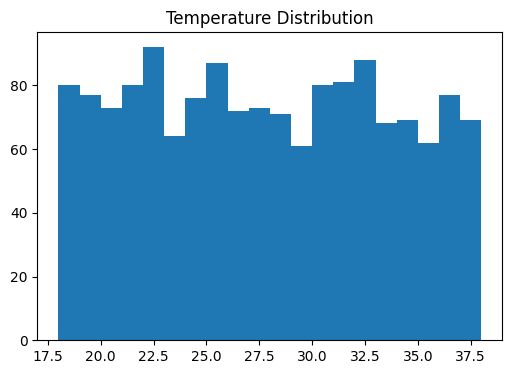

In [14]:
plt.figure(figsize=(6,4))

plt.hist(df['temperature_c'],
         bins=20)

plt.title("Temperature Distribution")

plt.show()

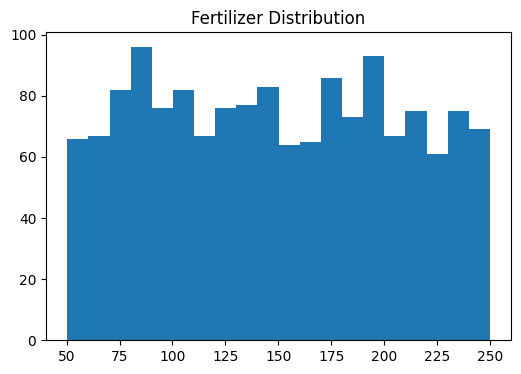

In [15]:
plt.figure(figsize=(6,4))

plt.hist(df['fertilizer_kg'],
         bins=20)

plt.title("Fertilizer Distribution")

plt.show()

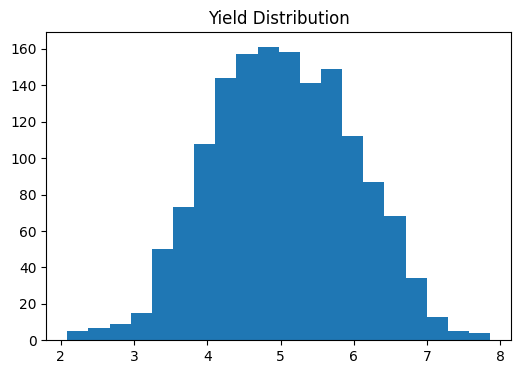

In [16]:
plt.figure(figsize=(6,4))

plt.hist(df['yield_ton_per_hectare'],
         bins=20)

plt.title("Yield Distribution")

plt.show()

In [17]:
df['crop_type'].value_counts()

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64

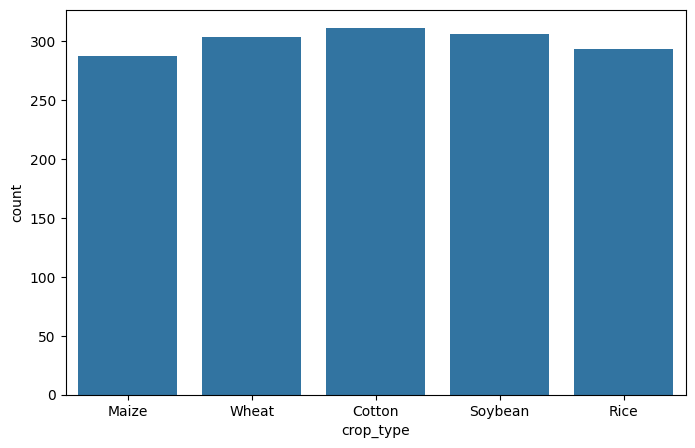

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='crop_type',
    data=df
)

plt.show()

In [19]:
df['crop_type'].mode()[0]

'Cotton'

In [20]:
df['soil_type'].value_counts()

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64

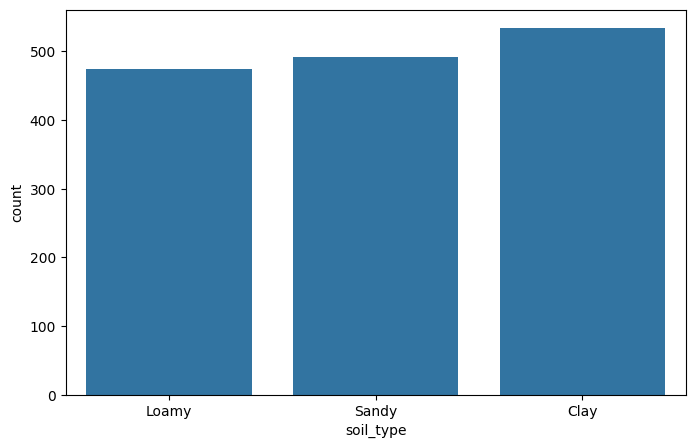

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='soil_type',
    data=df
)

plt.show()

In [22]:
df['soil_type'].mode()[0]

'Clay'

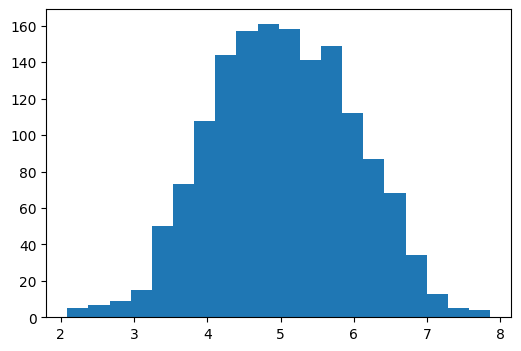

In [23]:
plt.figure(figsize=(6,4))

plt.hist(
    df['yield_ton_per_hectare'],
    bins=20
)

plt.show()

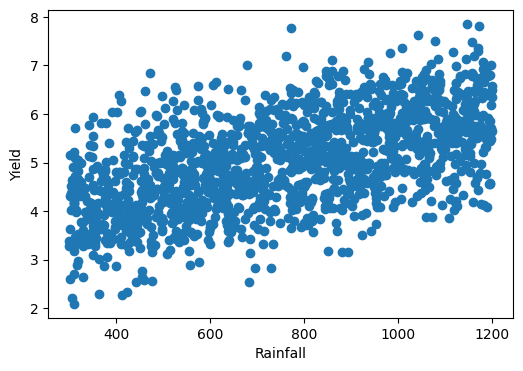

In [24]:
plt.figure(figsize=(6,4))

plt.scatter(
    df['rainfall_mm'],
    df['yield_ton_per_hectare']
)

plt.xlabel("Rainfall")
plt.ylabel("Yield")

plt.show()

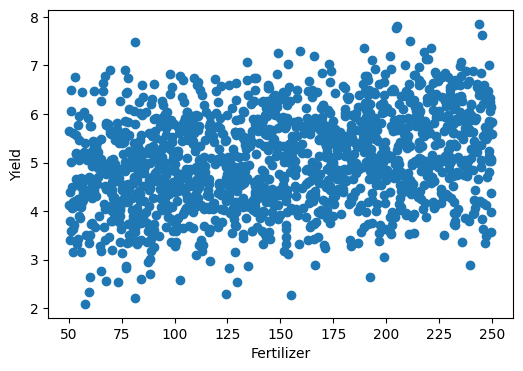

In [25]:
plt.figure(figsize=(6,4))

plt.scatter(
    df['fertilizer_kg'],
    df['yield_ton_per_hectare']
)

plt.xlabel("Fertilizer")
plt.ylabel("Yield")

plt.show()

In [26]:
corr = df.corr(
    numeric_only=True
)

corr

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
rainfall_mm,1.000000,0.026721,0.002558,0.010877,0.006916,0.553704
temperature_c,0.026721,1.000000,0.037468,0.007114,0.001513,-0.022559
fertilizer_kg,0.002558,0.037468,1.000000,-0.010497,0.010001,0.278043
irrigation_hours,0.010877,0.007114,-0.010497,1.000000,0.009307,0.542664
soil_ph,0.006916,0.001513,0.010001,0.009307,1.000000,0.024412
yield_ton_per_hectare,0.553704,-0.022559,0.278043,0.542664,0.024412,1.000000


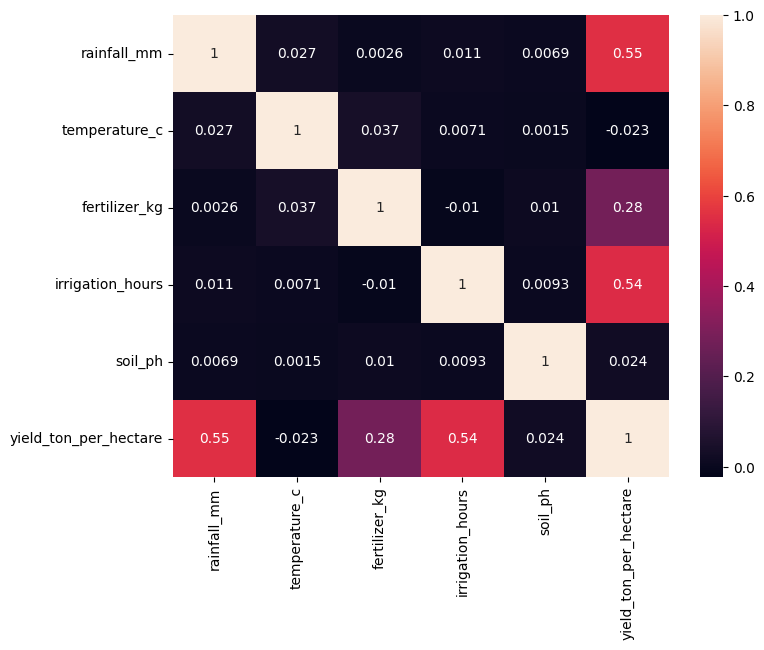

In [27]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True
)

plt.show()

In [28]:
corr['yield_ton_per_hectare']\
.sort_values(ascending=False)

yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
soil_ph                  0.024412
temperature_c           -0.022559
Name: yield_ton_per_hectare, dtype: float64

In [29]:
df.groupby(
    'crop_type'
)['yield_ton_per_hectare'].mean()

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64

In [30]:
df.groupby(
    'soil_type'
)['yield_ton_per_hectare'].mean()

soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

In [31]:
df.groupby(
    'crop_type'
)['yield_ton_per_hectare']\
.mean()\
.idxmax()

'Rice'

In [32]:
df.groupby(
    'soil_type'
)['yield_ton_per_hectare']\
.mean()\
.idxmax()

'Loamy'

In [33]:
df.select_dtypes(
    include='object'
).columns

C:\Users\ANIKET\AppData\Local\Temp\ipykernel_25076\25623309.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(


Index(['crop_type', 'soil_type'], dtype='str')

In [35]:
crop_type
soil_type

NameError: name 'crop_type' is not defined

In [36]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

In [37]:
df_encoded.head()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


In [38]:
y = df_encoded[
    'yield_ton_per_hectare'
]

In [40]:
X = df_encoded.drop(
    'yield_ton_per_hectare',
    axis=1
)

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [52]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1200, 11)
(300, 11)
(1200,)
(300,)


In [53]:
from sklearn.linear_model import LinearRegression

In [60]:
model = LinearRegression()

In [54]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](11,)","[ 0. ,-0.01, 0. ,..., 0.35, 0.3 ,-0.49]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](11,)","['rainfall_mm','temperature_c','fertilizer_kg',...,'crop_type_Wheat', 'soil_type_Loamy','soil_type_Sandy']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.587
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,11


In [55]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coef_df

,Feature,Coefficient
0,rainfall_mm,0.002035
1,temperature_c,-0.009175
2,fertilizer_kg,0.004978
3,irrigation_hours,0.198327
4,soil_ph,0.004901
5,crop_type_Maize,0.238931
6,crop_type_Rice,0.863993
7,crop_type_Soybean,0.481719
8,crop_type_Wheat,0.348474
9,soil_type_Loamy,0.302974


In [56]:
print("Intercept:", model.intercept_)

Intercept: 1.587132027736125


In [57]:
coef_df.sort_values(
    by='Coefficient',
    ascending=False
).head(1)

,Feature,Coefficient
6,crop_type_Rice,0.863993


In [58]:
y_pred = model.predict(X_test)

In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.2952480982114763
MSE: 0.1267285601229356
R2 Score: 0.8627866712142435
